In [16]:
from __future__ import print_function
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical


In [17]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 15386712056244205888
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 13565165568
locality {
  bus_id: 1
  links {
  }
}
incarnation: 8071687088136062465
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a"
xla_global_id: 416903419
]


W0000 00:00:1777912514.271351   37287 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1777912514.273562   37287 gpu_device.cc:2043] Created device /device:GPU:0 with 12936 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [18]:
  import os
  os.chdir('/home/g00n3r/projects/esp32_cl_har')

  column_names = ['user-id', 'activity', 'timestamp', 'x-axis', 'y-axis', 'z-axis']
  df = pd.read_csv("data/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt",
                   header=None,
                   names=column_names,
                   on_bad_lines='skip')
  df['z-axis'] = df['z-axis'].replace(regex=True, to_replace=r';', value=r'')
  df['z-axis'] = df['z-axis'].apply(lambda x: float(str(x).replace(',', '.')))
  df.dropna(axis=0, how='any', inplace=True)
  df.head(20)

,user-id,activity,timestamp,x-axis,y-axis,z-axis
0,33,Jogging,49105962326000,-0.694638,12.680544,0.503953
1,33,Jogging,49106062271000,5.012288,11.264028,0.953424
2,33,Jogging,49106112167000,4.903325,10.882658,-0.081722
3,33,Jogging,49106222305000,-0.612916,18.496431,3.023717
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164
5,33,Jogging,49106442306000,1.375655,-2.492524,-6.510526
6,33,Jogging,49106542312000,-0.612916,10.569390,5.706926
7,33,Jogging,49106652389000,-0.503953,13.947236,7.055340
8,33,Jogging,49106762313000,-8.430995,11.413852,5.134871
9,33,Jogging,49106872299000,0.953424,1.375655,1.648062


In [19]:
print('Number of columns in the dataframe: %i' % (df.shape[1]))
print('Number of rows in the dataframe: %i\n' % (df.shape[0]))

Number of columns in the dataframe: 6
Number of rows in the dataframe: 1086465



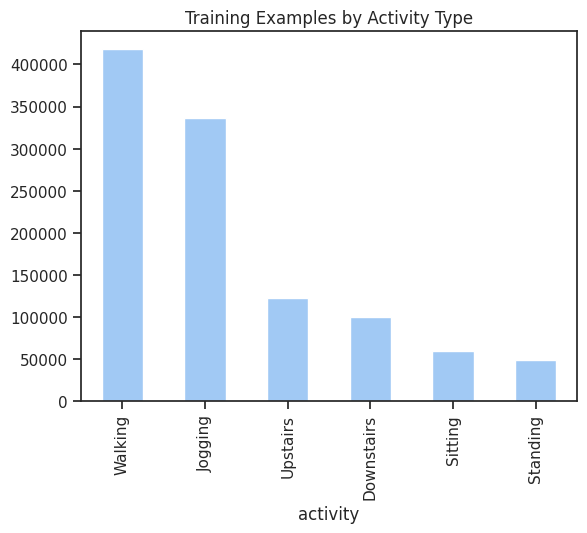

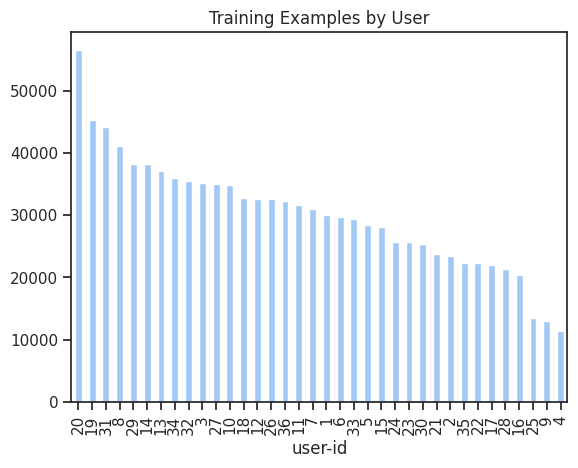

In [20]:
# Show how many training examples exist for each of the six activities
df['activity'].value_counts().plot(kind='bar',
                                   title='Training Examples by Activity Type')
plt.show()
# Better understand how the recordings are spread across the different
# users who participated in the study
df['user-id'].value_counts().plot(kind='bar',
                                  title='Training Examples by User')
plt.show()

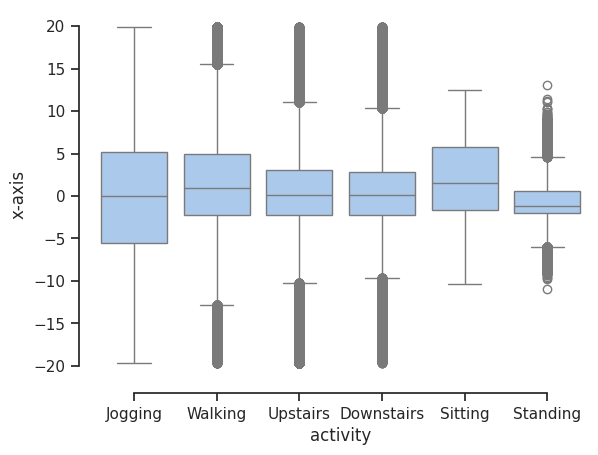

In [21]:
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")

# Draw a nested boxplot to show bills by day and time
sns.boxplot(data=df, x="activity", y="x-axis")
sns.despine(offset=10, trim=True)

## Розподіл прискорення по осі X для кожного типу активності

Boxplot відображає розподіл значень акселерометра (вісь X) по 6 класах активності з датасету WISDM.

- **Медіана** — горизонтальна лінія всередині box
- **IQR (25–75%)** — висота box
- **Вуса** — розкид без викидів

> Jogging і Upstairs мають найбільший розкид — характерно для динамічних рухів. Walking, Downstairs, Standing, Sitting — більш стабільні.


In [22]:
standing = df[df['activity'] == 'Standing']

Q1 = standing['x-axis'].quantile(0.25)
Q3 = standing['x-axis'].quantile(0.75)
IQR = Q3 - Q1

outliers = standing[
  (standing['x-axis'] < Q1 - 1.5 * IQR) |
  (standing['x-axis'] > Q3 + 1.5 * IQR)
]

print(f"Кількість викидів: {len(outliers)}")
print(outliers[['user-id', 'activity', 'x-axis']].describe())
outliers

Кількість викидів: 6095
           user-id       x-axis
count  6095.000000  6095.000000
mean     13.880886    -3.677358
std      10.377211     6.429887
min       5.000000   -10.990000
25%       7.000000    -7.930000
50%       8.000000    -7.350000
75%      31.000000     5.600000
max      31.000000    13.100000


,user-id,activity,timestamp,x-axis,y-axis,z-axis
223560,27,Standing,12542372296000,5.52,10.65,-2.451662
223561,27,Standing,12542422315000,-6.51,10.12,0.231546
400183,5,Standing,3210412273000,-6.66,6.32,-1.225831
542602,13,Standing,858492259000,-6.13,7.97,0.610000
542611,13,Standing,858942363000,-6.66,8.39,0.190000
...,...,...,...,...,...,...
1083695,19,Standing,131466241640000,-6.02,7.82,-0.500000
1083696,19,Standing,131466281496000,-6.09,7.78,-0.530000
1083724,19,Standing,131467691438000,-6.21,7.63,-0.530000
1083757,19,Standing,131469332857000,-6.09,8.47,0.080000


In [23]:
ACTIVITY_ORDER = ['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']
FEATURE_COLUMNS = ['x', 'y', 'z']
WINDOW_SIZE = 80
STEP_SIZE = 40  # 50% overlap
TIMESTAMP_GAP_FACTOR = 3.0

def prepare_dataframe(dataframe):
    df_model = dataframe.copy().rename(
        columns={
            'user-id': 'user_id',
            'x-axis': 'x',
            'y-axis': 'y',
            'z-axis': 'z',
        }
    )

    df_model = df_model[df_model['activity'].isin(ACTIVITY_ORDER)].copy()
    df_model['user_id'] = pd.to_numeric(df_model['user_id'], errors='coerce')
    df_model['timestamp'] = pd.to_numeric(df_model['timestamp'], errors='coerce')
    df_model[FEATURE_COLUMNS] = df_model[FEATURE_COLUMNS].apply(pd.to_numeric, errors='coerce')

    df_model = df_model.dropna(subset=['user_id', 'timestamp', *FEATURE_COLUMNS]).copy()
    df_model['user_id'] = df_model['user_id'].astype(np.int32)
    df_model['timestamp'] = df_model['timestamp'].astype(np.int64)
    df_model = df_model.sort_values(['user_id', 'activity', 'timestamp']).reset_index(drop=True)

    activity_to_label = {activity: idx for idx, activity in enumerate(ACTIVITY_ORDER)}
    label_to_activity = {idx: activity for activity, idx in activity_to_label.items()}
    df_model['label'] = df_model['activity'].map(activity_to_label).astype(np.int32)

    return df_model, activity_to_label, label_to_activity

def add_contiguous_segments(dataframe, timestamp_gap_factor=TIMESTAMP_GAP_FACTOR):
    segmented_groups = []

    for (_, _), group in dataframe.groupby(['user_id', 'activity'], sort=False):
        group = group.sort_values('timestamp').copy()
        deltas = group['timestamp'].diff()
        positive_deltas = deltas[deltas > 0]

        if positive_deltas.empty:
            gap_threshold = np.inf
        else:
            gap_threshold = positive_deltas.median() * timestamp_gap_factor

        new_segment = deltas.isna() | (deltas <= 0) | (deltas > gap_threshold)
        group['segment_id'] = new_segment.cumsum().astype(np.int32)
        segmented_groups.append(group)

    return pd.concat(segmented_groups, ignore_index=True)

df_model, activity_to_label, label_to_activity = prepare_dataframe(df)
df_model = add_contiguous_segments(df_model)

print(f"Rows after cleanup: {len(df_model):,}")
print(f"Subjects: {df_model['user_id'].nunique()}")
print(f"Activities: {sorted(df_model['activity'].unique().tolist())}")
print(f"Segments: {df_model.groupby(['user_id', 'activity', 'segment_id']).ngroups:,}")

display(df_model.groupby('activity').size().rename('rows').to_frame())
display(df_model.groupby('user_id')['activity'].nunique().describe().to_frame().T)

df_model.head()


Rows after cleanup: 1,086,465
Subjects: 36
Activities: ['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']
Segments: 74,932


,rows
activity,
Downstairs,100425
Jogging,336445
Sitting,59939
Standing,48394
Upstairs,122869
Walking,418393


,count,mean,std,min,25%,50%,75%,max
activity,36.0,4.972222,1.341345,1.0,4.0,6.0,6.0,6.0


,user_id,activity,timestamp,x,y,z,label,segment_id
0,1,Downstairs,6552942304000,-0.15,9.15,-0.34,3,1
1,1,Downstairs,6552992292000,0.11,9.19,2.76,3,1
2,1,Downstairs,6553042310000,-4.06,7.40,4.02,3,1
3,1,Downstairs,6553092298000,-2.87,7.93,3.21,3,1
4,1,Downstairs,6553142347000,-0.19,10.04,4.82,3,1


In [24]:
def fit_zscore_stats(dataframe, feature_columns):
    means = dataframe[feature_columns].mean()
    stds = dataframe[feature_columns].std().replace(0, 1.0)
    return means, stds

def apply_zscore_stats(dataframe, feature_columns, means, stds):
    scaled = dataframe.copy()
    scaled[feature_columns] = (scaled[feature_columns] - means) / stds
    return scaled

def create_windows_from_segments(dataframe, feature_columns, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    windows = []
    labels = []
    subject_ids = []

    grouped = dataframe.groupby(['user_id', 'activity', 'segment_id'], sort=False)

    for (user_id, activity, segment_id), group in grouped:
        values = group[feature_columns].to_numpy(dtype=np.float32)
        label = int(group['label'].iloc[0])

        if len(values) < window_size:
            continue

        for start in range(0, len(values) - window_size + 1, step_size):
            end = start + window_size
            windows.append(values[start:end])
            labels.append(label)
            subject_ids.append(user_id)

    if not windows:
        empty_X = np.empty((0, window_size, len(feature_columns)), dtype=np.float32)
        empty_y = np.empty((0,), dtype=np.int32)
        empty_subjects = np.empty((0,), dtype=np.int32)
        return empty_X, empty_y, empty_subjects

    X = np.stack(windows).astype(np.float32)
    y = np.asarray(labels, dtype=np.int32)
    subjects = np.asarray(subject_ids, dtype=np.int32)
    return X, y, subjects


In [25]:
def build_one_fold_data(dataframe, test_subject_id, feature_columns=FEATURE_COLUMNS, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    train_df = dataframe[dataframe['user_id'] != test_subject_id].copy()
    test_df = dataframe[dataframe['user_id'] == test_subject_id].copy()

    train_means, train_stds = fit_zscore_stats(train_df, feature_columns)
    train_scaled = apply_zscore_stats(train_df, feature_columns, train_means, train_stds)
    test_scaled = apply_zscore_stats(test_df, feature_columns, train_means, train_stds)

    X_train, y_train, train_subjects = create_windows_from_segments(
        train_scaled,
        feature_columns,
        window_size=window_size,
        step_size=step_size,
    )
    X_test, y_test, test_subjects = create_windows_from_segments(
        test_scaled,
        feature_columns,
        window_size=window_size,
        step_size=step_size,
    )

    return {
        'train_df': train_scaled,
        'test_df': test_scaled,
        'train_means': train_means,
        'train_stds': train_stds,
        'X_train': X_train,
        'y_train': y_train,
        'train_subjects': train_subjects,
        'X_test': X_test,
        'y_test': y_test,
        'test_subjects': test_subjects,
        'y_train_onehot': to_categorical(y_train, num_classes=len(ACTIVITY_ORDER)),
        'y_test_onehot': to_categorical(y_test, num_classes=len(ACTIVITY_ORDER)),
    }

TEST_SUBJECT_ID = 1
fold_data = build_one_fold_data(df_model, test_subject_id=TEST_SUBJECT_ID)

X_train = fold_data['X_train']
y_train = fold_data['y_train']
train_subjects = fold_data['train_subjects']
y_train_onehot = fold_data['y_train_onehot']

X_test = fold_data['X_test']
y_test = fold_data['y_test']
test_subjects = fold_data['test_subjects']
y_test_onehot = fold_data['y_test_onehot']

print(f"Train windows: {X_train.shape[0]}")
print(f"Test windows: {X_test.shape[0]}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

print('Train z-score means:')
display(fold_data['train_means'].to_frame(name='mean').T)
print('Train z-score stds:')
display(fold_data['train_stds'].to_frame(name='std').T)


Train windows: 8796
Test windows: 358
Train shape: (8796, 80, 3)
Test shape: (358, 80, 3)
Train z-score means:


,x,y,z
mean,0.71894,7.294946,0.397504


Train z-score stds:


,x,y,z
std,6.802717,6.680828,4.767268


In [26]:
print('NaN in X_train:', np.isnan(X_train).sum())
print('Inf in X_train:', np.isinf(X_train).sum())
print('NaN in X_test:', np.isnan(X_test).sum())
print('Inf in X_test:', np.isinf(X_test).sum())

assert X_train.shape[1:] == (WINDOW_SIZE, len(FEATURE_COLUMNS))
assert X_test.shape[1:] == (WINDOW_SIZE, len(FEATURE_COLUMNS))
assert np.all(train_subjects != TEST_SUBJECT_ID)
assert np.all(test_subjects == TEST_SUBJECT_ID)

train_window_counts = pd.Series(train_subjects).value_counts().sort_index()
test_window_counts = pd.Series(test_subjects).value_counts().sort_index()

print('Train windows per subject:')
display(train_window_counts.to_frame(name='n_windows'))
print('Test windows per subject:')
display(test_window_counts.to_frame(name='n_windows'))

print('Train class distribution:')
display(pd.Series(y_train).map(label_to_activity).value_counts().rename_axis('activity').to_frame('windows'))
print('Test class distribution:')
display(pd.Series(y_test).map(label_to_activity).value_counts().rename_axis('activity').to_frame('windows'))

print('y_train_onehot shape:', y_train_onehot.shape)
print('y_test_onehot shape:', y_test_onehot.shape)


NaN in X_train: 0
Inf in X_train: 0
NaN in X_test: 0
Inf in X_test: 0
Train windows per subject:


,n_windows
2,319
3,339
4,117
5,225
6,164
7,303
8,359
9,169
10,359
11,315


Test windows per subject:


,n_windows
1,358


Train class distribution:


,windows
activity,
Walking,4115
Jogging,2042
Upstairs,1167
Downstairs,923
Standing,369
Sitting,180


Test class distribution:


,windows
activity,
Walking,187
Jogging,91
Upstairs,44
Downstairs,36


y_train_onehot shape: (8796, 6)
y_test_onehot shape: (358, 6)


In [27]:
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = len(ACTIVITY_ORDER)
INPUT_SHAPE = (WINDOW_SIZE, len(FEATURE_COLUMNS))

def build_baseline_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(num_classes, activation='softmax'),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 80, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 80, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,110 (27.77 KB)

 Trainable params: 7,110 (27.77 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
BATCH_SIZE = 64
EPOCHS = 10

print(f"Train windows: {X_train.shape[0]}")
print(f"Test windows: {X_test.shape[0]}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

model = build_baseline_model()

history = model.fit(
    X_train,
    y_train_onehot,
    validation_data=(X_test, y_test_onehot),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

test_loss, test_acc = model.evaluate(X_test, y_test_onehot, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Train windows: 8796
Test windows: 358
Train shape: (8796, 80, 3)
Test shape: (358, 80, 3)
Epoch 1/10


I0000 00:00:1777912532.858561  159623 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20608__.18


 98/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5045 - loss: 1.4192  

I0000 00:00:1777912533.506727  159618 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20608__.18


138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5280 - loss: 1.3506

I0000 00:00:1777912535.445148  167088 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 4 bytes spill stores, 4 bytes spill loads



138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6020 - loss: 1.1396 - val_accuracy: 0.7765 - val_loss: 0.7946
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7350 - loss: 0.7120 - val_accuracy: 0.7765 - val_loss: 0.7015
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8093 - loss: 0.5391 - val_accuracy: 0.7682 - val_loss: 0.7030
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8299 - loss: 0.4618 - val_accuracy: 0.7765 - val_loss: 0.7711
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8479 - loss: 0.4181 - val_accuracy: 0.7737 - val_loss: 0.7442
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8587 - loss: 0.3845 - val_accuracy: 0.7682 - val_loss: 0.8824
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8707 - loss: 0.3571 - val_accuracy: 0.7570 - val_loss: 0.7535
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8837 - loss: 0.3310 - val_accuracy: 0.7430 - val